# 2 — Watching a run

A run gives **two** answers, and they come out of different holes. `forward`
returns a value when it is over; `watching=` is told things while it is going.
That difference is the whole of this notebook: a curve drawn after the run is a
report, and what you want at three in the morning is a view.

Observability here is three separate things, and CU19 split them on purpose:

| | what it is | needs |
|---|---|---|
| the declaration, **drawn** | notebook 1 — a graph can be drawn having never run | nothing |
| the record of what **happened** | facts; the residue of running | a store |
| the **diagnosis** | *an opinion about the facts*, with arguable thresholds | the record |

This notebook is the middle row. The third does not exist yet.

In [1]:
import tempfile

from soma_next import Graph, Node, Recorder, Store
from soma_next.record import Live, curve, curve_costs, facts, forwards, nodes, progress, runs, spent


class Tokenize(Node):
    def forward(self, text, ctx):
        return [float(len(word)) for word in text.split()]


class Embed(Node):
    def forward(self, counts, ctx):
        return [n * 0.5 for n in counts]


class Score(Node):
    def forward(self, values, ctx):
        return sum(values) / len(values)


g = Graph.somatize(Tokenize().named("tokenize") >> Embed().named("embed") >> Score().named("score"))

## Anything callable is told

A fact arrives as a `dict` with a `fact` key naming it and text beside it. That
is **the same shape it is written down as**, so what you print is what you would
find in the store afterwards.

In [2]:
g.forward("the quick brown fox", watching=print)

{'fact': 'ran', 'node': 'tokenize', 'began_us': '5', 'took_us': '69'}
{'fact': 'ran', 'node': 'embed', 'began_us': '207', 'took_us': '220'}
{'fact': 'ran', 'node': 'score', 'began_us': '484', 'took_us': '79'}
{'fact': 'finished', 'took_us': '625'}


2.0

The vocabulary is the engine's, and it is closed: `ran`, `failed`, `recalled`,
`kept`, `items`, `left`, `finished`, `broke`. Nothing here is a judgement —
whether 400 µs is slow is an opinion, and opinions are CU21.

## A `Recorder` keeps it

One record per `forward`, at `run/<id>/<n>`. `summarising=["loss"]` puts named
facts **into the record** rather than only into its blob, which is what makes
reading them back later cost one scan instead of one fetch per step.

In [3]:
store = Store(tempfile.mkdtemp())
recorder = Recorder(store, run="tuesday", summarising=["loss"])

for step in range(40):
    g.forward("the quick brown fox jumps", watching=recorder)
    # A level above the engine says its own things, through the same door. The
    # core never learns what a loss is: the two vocabularies meet in the record.
    recorder({"fact": "loss", "value": 2.0 * 0.93**step + 0.1})

print(recorder.run, "->", len(store.bound()), "records")

tuesday -> 40 records


## Reading it back is a price list

| call | answers | costs |
|---|---|---|
| `runs` | what is in here at all | one scan |
| `forwards` | step by step | one scan |
| `curve` | the series somebody plots | one scan\* |
| `facts` | everything one step did | one fetch |
| `nodes` | who spent the time, added up | a fetch per `forward` |

\* free only for what the recorder was told to summarise. `curve_costs` says
which of the two it did, because a reader that is quietly a thousand times
slower is worse than one that says so.

In [4]:
runs(store)

[{'run': 'tuesday',
  'forwards': 40,
  'broke': 0,
  'took_us': 3838,
  'first': 1787489055,
  'last': 1787489055}]

In [5]:
forwards(store, run="tuesday")[:3]

[{'forward': 0,
  'state': 'ok',
  'nodes': 3,
  'took_us': 305,
  'loss.value': '2.1',
  'when': 1787489055},
 {'forward': 1,
  'state': 'ok',
  'nodes': 3,
  'took_us': 169,
  'loss.value': '1.9600000000000002',
  'when': 1787489055},
 {'forward': 2,
  'state': 'ok',
  'nodes': 3,
  'took_us': 165,
  'loss.value': '1.8298000000000003',
  'when': 1787489055}]

In [6]:
print(curve_costs(store, run="tuesday"), curve(store, run="tuesday")[:5])

scan [(0, 2.1), (1, 1.9600000000000002), (2, 1.8298000000000003), (3, 1.7087140000000003), (4, 1.5961040200000005)]


In [7]:
facts(store, run="tuesday", forward=0)

[{'began_us': '4', 'fact': 'ran', 'node': 'tokenize', 'took_us': '59'},
 {'began_us': '96', 'fact': 'ran', 'node': 'embed', 'took_us': '82'},
 {'began_us': '191', 'fact': 'ran', 'node': 'score', 'took_us': '84'},
 {'fact': 'finished', 'took_us': '305'},
 {'fact': 'loss', 'value': '2.1'}]

`nodes` is the aggregated view, and the one that answers *is the profiling
reasonable*. It is the expensive call, so it is asked once and not once a step
— `last=N` reads only the tail, which is the question worth asking of a run
that is ten thousand steps long.

In [8]:
nodes(store, run="tuesday")

[{'node': 'tokenize',
  'ran': 40,
  'recalled': 0,
  'failed': 0,
  'took_us': 1120,
  'hosts': [],
  'devices': [],
  'mean_us': 28.0},
 {'node': 'embed',
  'ran': 40,
  'recalled': 0,
  'failed': 0,
  'took_us': 861,
  'hosts': [],
  'devices': [],
  'mean_us': 21.525},
 {'node': 'score',
  'ran': 40,
  'recalled': 0,
  'failed': 0,
  'took_us': 535,
  'hosts': [],
  'devices': [],
  'mean_us': 13.375}]

## Drawn

`progress` reads the store. The bold line is a **centred rolling mean**, not a
spline through the points: a spline invents the values between them, and an
overshoot dipping below a minimum that never happened is a figure that lies.
The raw series stays underneath it, thin, so nothing is hidden by the smoothing.

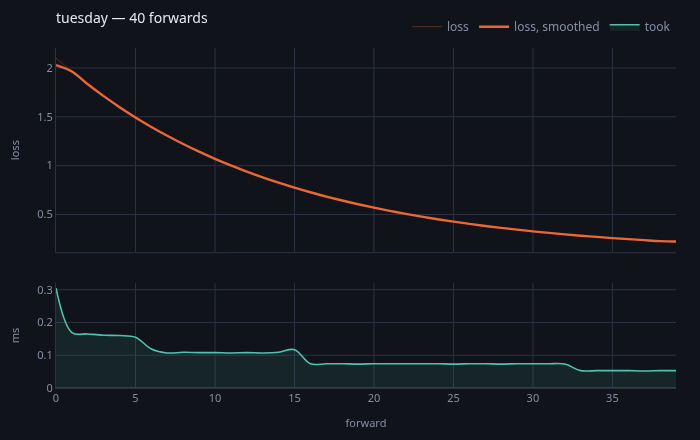

In [9]:
progress(store, run="tuesday")

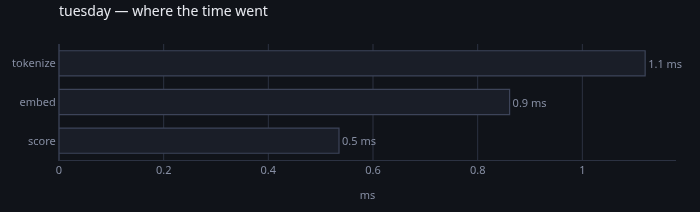

In [10]:
spent(store, run="tuesday")

## The same figure, live

`Live` is handed facts as they happen and fills **the same drawing function**
as `progress`. It can, because a fact read back is the very dict a watcher was
given. A live view and a report written twice are two things that slowly stop
agreeing.

With `ipywidgets` installed, `live.widget()` redraws in place; without one it
still tallies everything and the cell shows the figure at any moment.

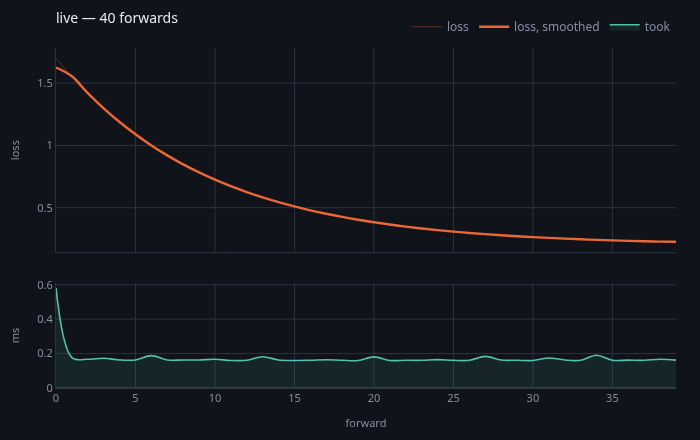

In [11]:
live = Live(title="live")

for step in range(40):
    g.forward("the quick brown fox jumps", watching=live)
    live({"fact": "loss", "value": 1.5 * 0.9**step + 0.2})

live

## The cache, seen

A hit and a miss are two different facts, and a hit says nothing about a node
having run — because it did not. `.cached()` needs `.frozen()` to be honest:
what is kept has to be settled, or the name would point at a value the code no
longer produces.

In [12]:
kept = tempfile.mkdtemp()
cached = Graph.somatize(
    Tokenize().named("tokenize").frozen().cached() >> Embed().named("embed") >> Score().named("score")
)

for _ in range(2):
    cached.forward("the quick brown fox", store=kept, watching=lambda f: print(f["fact"], f.get("node", "")))
    print("--")

ran tokenize
kept tokenize
ran embed
ran score
finished 
--
recalled tokenize
ran embed
ran score
finished 
--


## A node on another machine

`.at("w1")` sends a node to a worker, and what happens over there **comes back
down the connection that is already open** — the client was blocked reading it
anyway. No second port, no bus.

A worker does not know what it is called: the host's name is the graph's, so
the client is the one that stamps it.

In [13]:
import sys

from soma_next import Worker

remote = Graph.somatize(
    Tokenize().named("tokenize") >> Embed().named("embed").at("w1") >> Score().named("score")
)
# `mode="network"` sends the code, which is what a node defined in this notebook
# needs: nothing over there could import it. A node that lives in a module the
# worker already has is `mode="project"` and travels as a name.
worker = Worker.spawn([sys.executable, "-m", "soma_next.worker"], mode="network")

seen = []
print(remote.forward("the quick brown fox", workers={"w1": worker}, watching=seen.append))
for one in seen:
    print(one)

2.0
{'fact': 'ran', 'node': 'tokenize', 'began_us': '3', 'took_us': '38'}
{'fact': 'ran', 'node': 'embed', 'began_us': '12', 'took_us': '36', 'host': 'w1'}
{'fact': 'left', 'host': 'w1', 'began_us': '74', 'took_us': '1193003'}
{'fact': 'ran', 'node': 'score', 'began_us': '1193101', 'took_us': '36'}
{'fact': 'finished', 'took_us': '1193166'}


The `left` on that first trip is about a second, and almost none of it is the
wire: it is the worker starting, greeting, and being handed the artifact with
the code in it. **The next trip pays none of that** — the session is open and
the worker already holds the catalog — and that is the number worth reading.

In [14]:
for again in range(3):
    seen = []
    remote.forward("with the worker already up", workers={"w1": worker}, watching=seen.append)
    print([one for one in seen if one["fact"] == "left"])

[{'fact': 'left', 'host': 'w1', 'began_us': '69', 'took_us': '435'}]
[{'fact': 'left', 'host': 'w1', 'began_us': '64', 'took_us': '227'}]
[{'fact': 'left', 'host': 'w1', 'began_us': '51', 'took_us': '216'}]
